**Dokumentasi Analisis Data Bike Sharing**

1. Pendahuluan

Aplikasi ini bertujuan untuk menganalisis data peminjaman sepeda dan memberikan wawasan tentang pola peminjaman berdasarkan hari, cuaca, serta melakukan prediksi menggunakan model machine learning.

2. Load Data

Pertama, dataset yang terdiri dari dua file CSV (day.csv dan hour.csv) dimuat ke dalam aplikasi menggunakan pandas.


In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings("ignore")

# Load dataset
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

Dataset day.csv berisi informasi harian mengenai peminjaman sepeda, sementara hour.csv menyajikan data per jam.

3. Visualisasi Grafik Peminjaman Sepeda Harian

Visualisasi ini menampilkan jumlah peminjaman sepeda berdasarkan hari dalam seminggu.

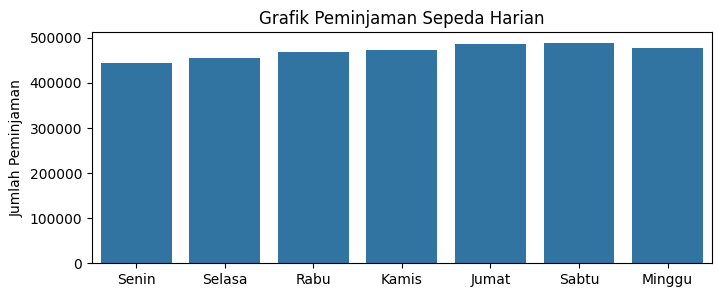

In [27]:
%matplotlib inline
# Visualisasi peminjaman sepeda harian
day_df["weekday"] = pd.Categorical(day_df["weekday"], categories=[0,1,2,3,4,5,6], ordered=True)
weekly_data = day_df.groupby("weekday")["cnt"].sum()

plt.figure(figsize=(8, 3))
sns.barplot(x=["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"], y=weekly_data.values)
plt.ylabel("Jumlah Peminjaman")
plt.title("Grafik Peminjaman Sepeda Harian")
plt.show()

Dari grafik ini, kita dapat mengidentifikasi hari dengan peminjaman terbanyak dan paling sedikit.

4. Pengaruh Cuaca terhadap Peminjaman

Menganalisis bagaimana kondisi cuaca memengaruhi jumlah peminjaman sepeda.

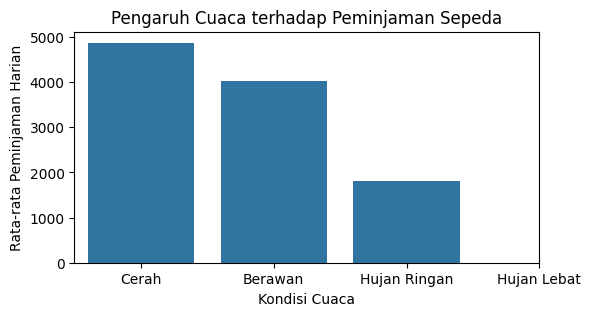

In [28]:
# Pengaruh cuaca terhadap peminjaman
weather_data = day_df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(6, 3))
sns.barplot(x=weather_data.index, y=weather_data.values)
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Peminjaman Harian")
plt.xticks(ticks=[0,1,2,3], labels=["Cerah", "Berawan", "Hujan Ringan", "Hujan Lebat"])
plt.title("Pengaruh Cuaca terhadap Peminjaman Sepeda")
plt.show()

Dari hasil visualisasi, semakin buruk kondisi cuaca, semakin sedikit jumlah peminjaman sepeda.

5. Prediksi Peminjaman Sepeda

Menggunakan model RandomForestRegressor untuk memprediksi jumlah peminjaman berdasarkan hari dan kondisi cuaca.

In [29]:
# Prediksi jumlah peminjaman
X = day_df[["weekday", "weathersit"]]
y = day_df["cnt"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Input untuk prediksi
day_options = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]
weather_options = ["Cerah", "Berawan", "Hujan Ringan", "Hujan Lebat"]

selected_day = input("Pilih Hari (Senin-Minggu): ")
selected_weather = input("Pilih Kondisi Cuaca (Cerah, Berawan, Hujan Ringan, Hujan Lebat): ")

pred = model.predict([[day_options.index(selected_day), weather_options.index(selected_weather)]])
print(f"Prediksi Jumlah Peminjaman: {int(pred[0])} Sepeda")

Pilih Hari (Senin-Minggu):  Selasa
Pilih Kondisi Cuaca (Cerah, Berawan, Hujan Ringan, Hujan Lebat):  Berawan


Prediksi Jumlah Peminjaman: 4729 Sepeda


Dengan memilih hari dan kondisi cuaca, aplikasi akan memberikan prediksi jumlah peminjaman sepeda.

6. Informasi Kelompok

Menampilkan informasi anggota kelompok yang mengembangkan aplikasi ini.

In [30]:
# Informasi kelompok
print("Kelompok 4")
print("Anggota Kelompok:")
print("- Afifah Nurfadhilah - 10123168")
print("- Aulia Maysaroh Mardiansyah - 10123160")
print("- Bintang Kurnia Saputra - 10123161")
print("- Dimas Perkasa Agung Putra - 10123133")
print("- Putu Adi Pratama - 10123137")
print("- Riska Oktaviani - 10123142")

Kelompok 4
Anggota Kelompok:
- Afifah Nurfadhilah - 10123168
- Aulia Maysaroh Mardiansyah - 10123160
- Bintang Kurnia Saputra - 10123161
- Dimas Perkasa Agung Putra - 10123133
- Putu Adi Pratama - 10123137
- Riska Oktaviani - 10123142


7. Kesimpulan

Aplikasi ini membantu dalam memahami pola peminjaman sepeda berdasarkan hari dan kondisi cuaca serta mampu memprediksi jumlah peminjaman dengan model machine learning. Dengan adanya visualisasi data dan prediksi, pengguna dapat memperoleh wawasan yang lebih baik mengenai pola peminjaman sepeda.